# ***Load Libraries***

In [ ]:
pip install streamlit joblib pandas scikit-learn

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,power_transform,OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier,GradientBoostingClassifier,AdaBoostClassifier,ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score,recall_score,ConfusionMatrixDisplay,f1_score,roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [179]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [180]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [181]:
df.shape

(768, 9)

In [182]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [184]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [185]:
df.duplicated().sum()

np.int64(0)

In [186]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [187]:
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [188]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [189]:
df.cov()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,11.354056,13.947131,9.214538,-4.390041,-28.555231,0.469774,-0.037426,21.570620,0.356618
Glucose,13.947131,1022.248314,94.430956,29.239183,1220.935799,55.726987,1.454875,99.082805,7.115079
BloodPressure,9.214538,94.430956,374.647271,64.029396,198.378412,43.004695,0.264638,54.523453,0.600697
SkinThickness,-4.390041,29.239183,64.029396,254.473245,802.979941,49.373869,0.972136,-21.381023,0.568747
Insulin,-28.555231,1220.935799,198.378412,802.979941,13281.180078,179.775172,7.066681,-57.143290,7.175671
BMI,0.469774,55.726987,43.004695,49.373869,179.775172,62.159984,0.367405,3.360330,1.100638
DiabetesPedigreeFunction,-0.037426,1.454875,0.264638,0.972136,7.066681,0.367405,0.109779,0.130772,0.027472
Age,21.570620,99.082805,54.523453,-21.381023,-57.143290,3.360330,0.130772,138.303046,1.336953
Outcome,0.356618,7.115079,0.600697,0.568747,7.175671,1.100638,0.027472,1.336953,0.227483


In [190]:
df.skew()

,0
Pregnancies,0.901674
Glucose,0.173754
BloodPressure,-1.843608
SkinThickness,0.109372
Insulin,2.272251
BMI,-0.428982
DiabetesPedigreeFunction,1.919911
Age,1.129597
Outcome,0.635017


In [191]:
df.kurtosis()

,0
Pregnancies,0.159220
Glucose,0.640780
BloodPressure,5.180157
SkinThickness,-0.520072
Insulin,7.214260
BMI,3.290443
DiabetesPedigreeFunction,5.594954
Age,0.643159
Outcome,-1.600930


In [192]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


# *Data Visaulization*

<Axes: >

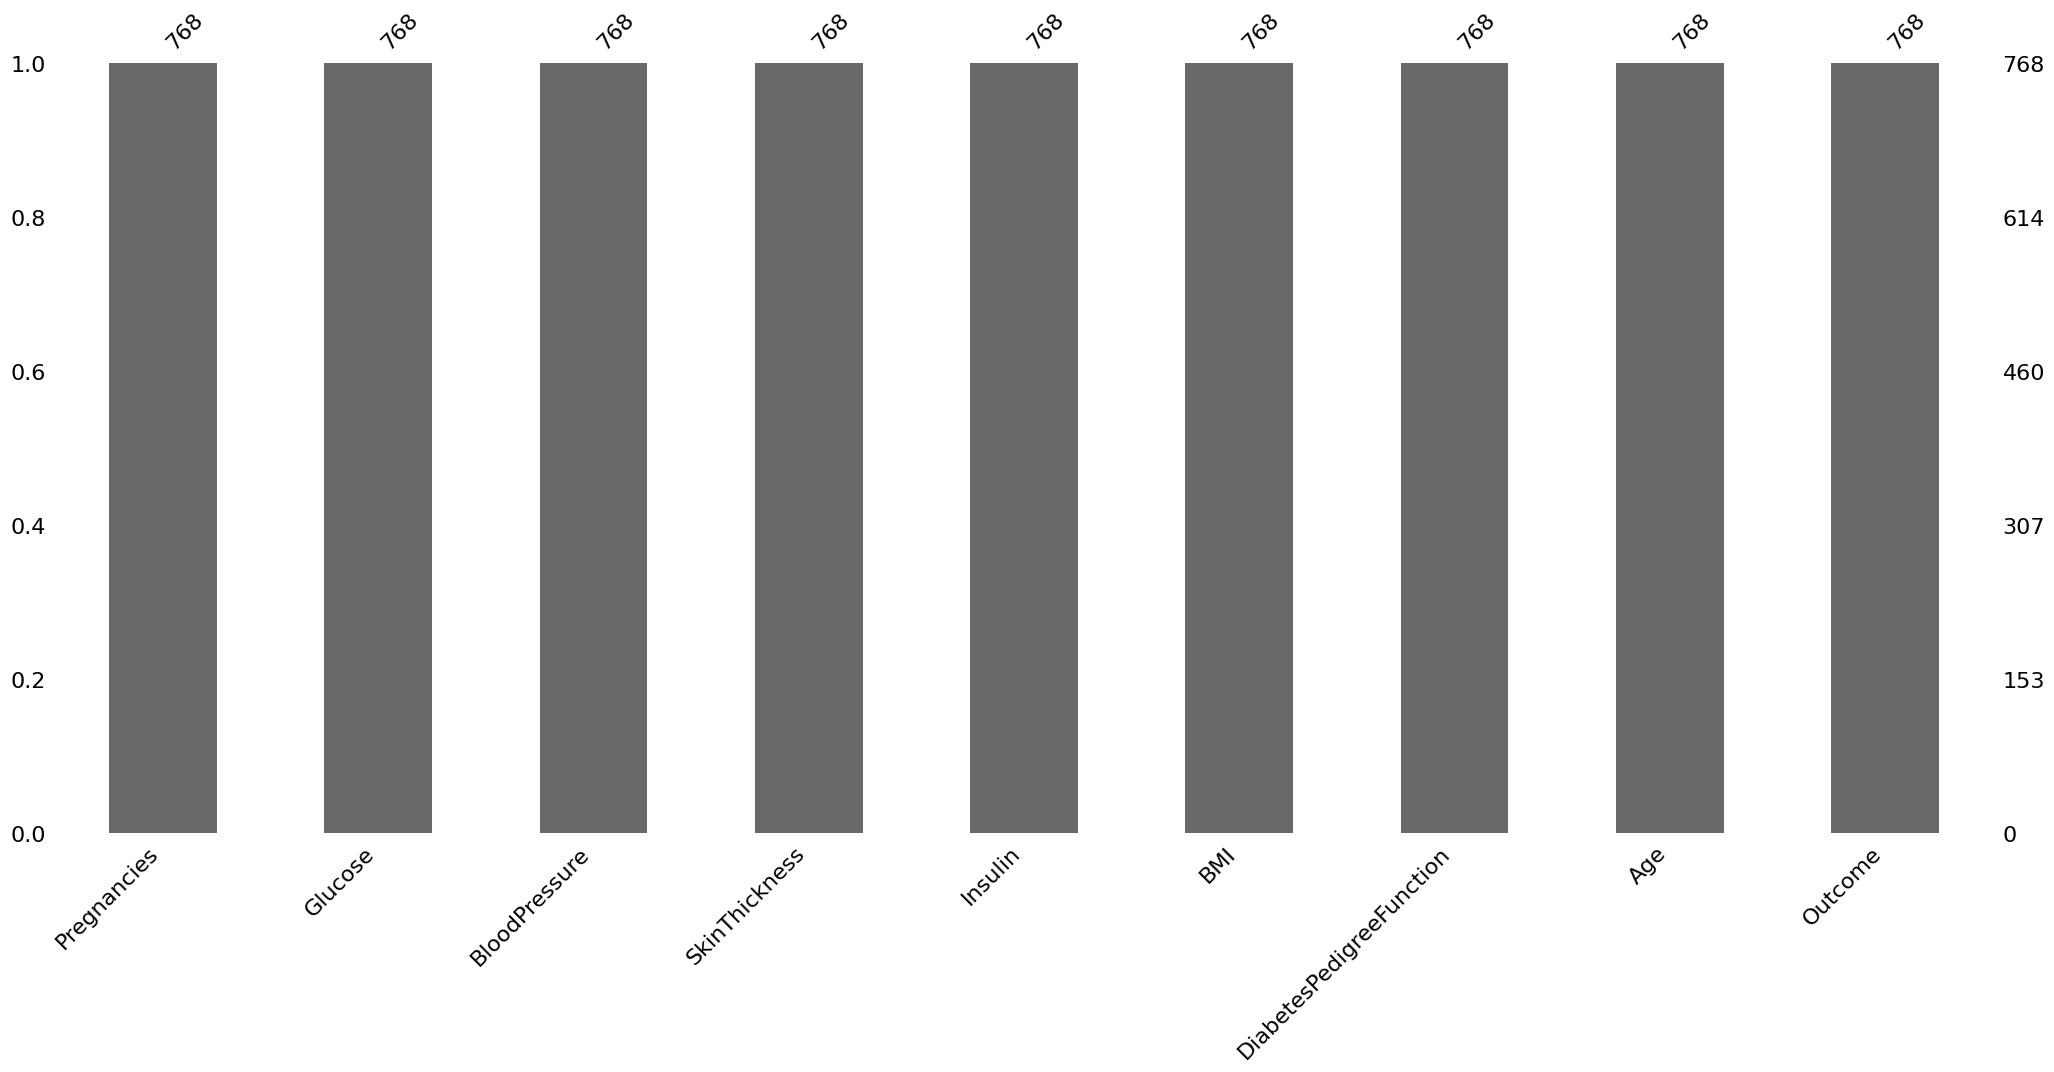

In [193]:
import missingno
missingno.bar(df)

<Figure size 1300x800 with 0 Axes>

<Axes: >

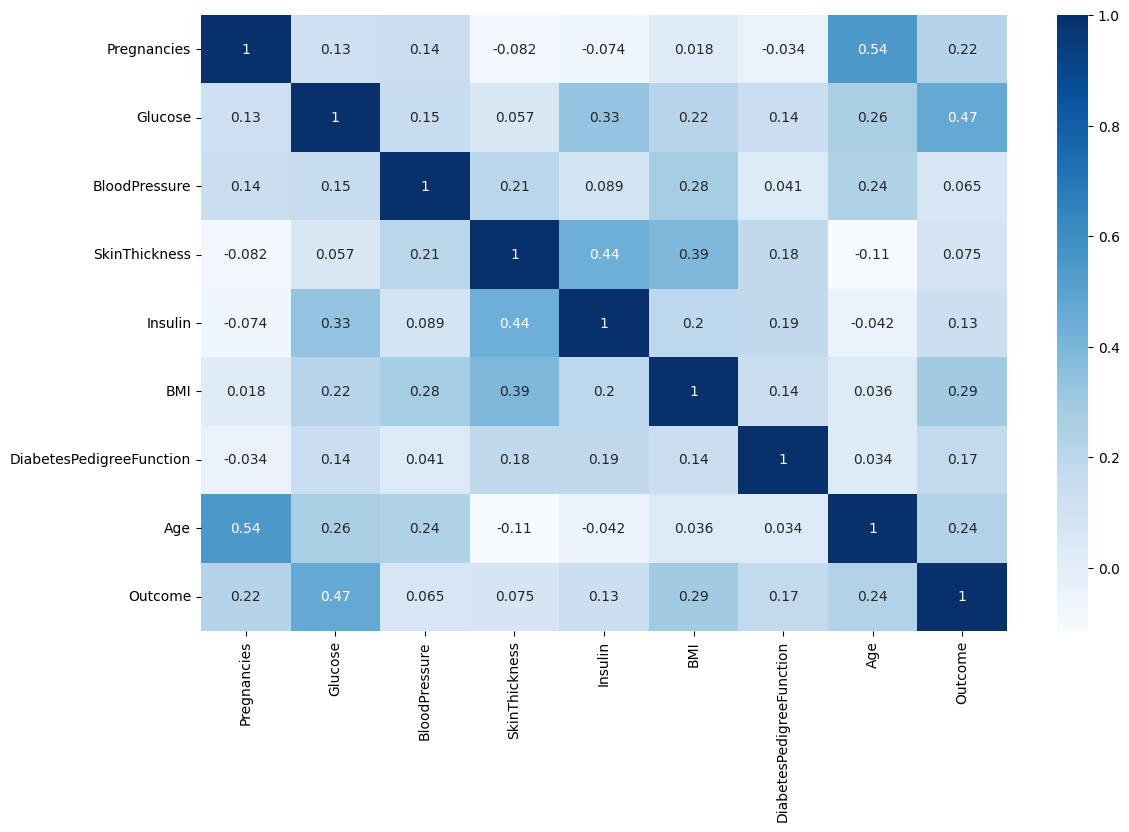

In [194]:
plt.figure(figsize=(13,8))
sns.heatmap(df.corr(),annot=True,cmap='Blues')

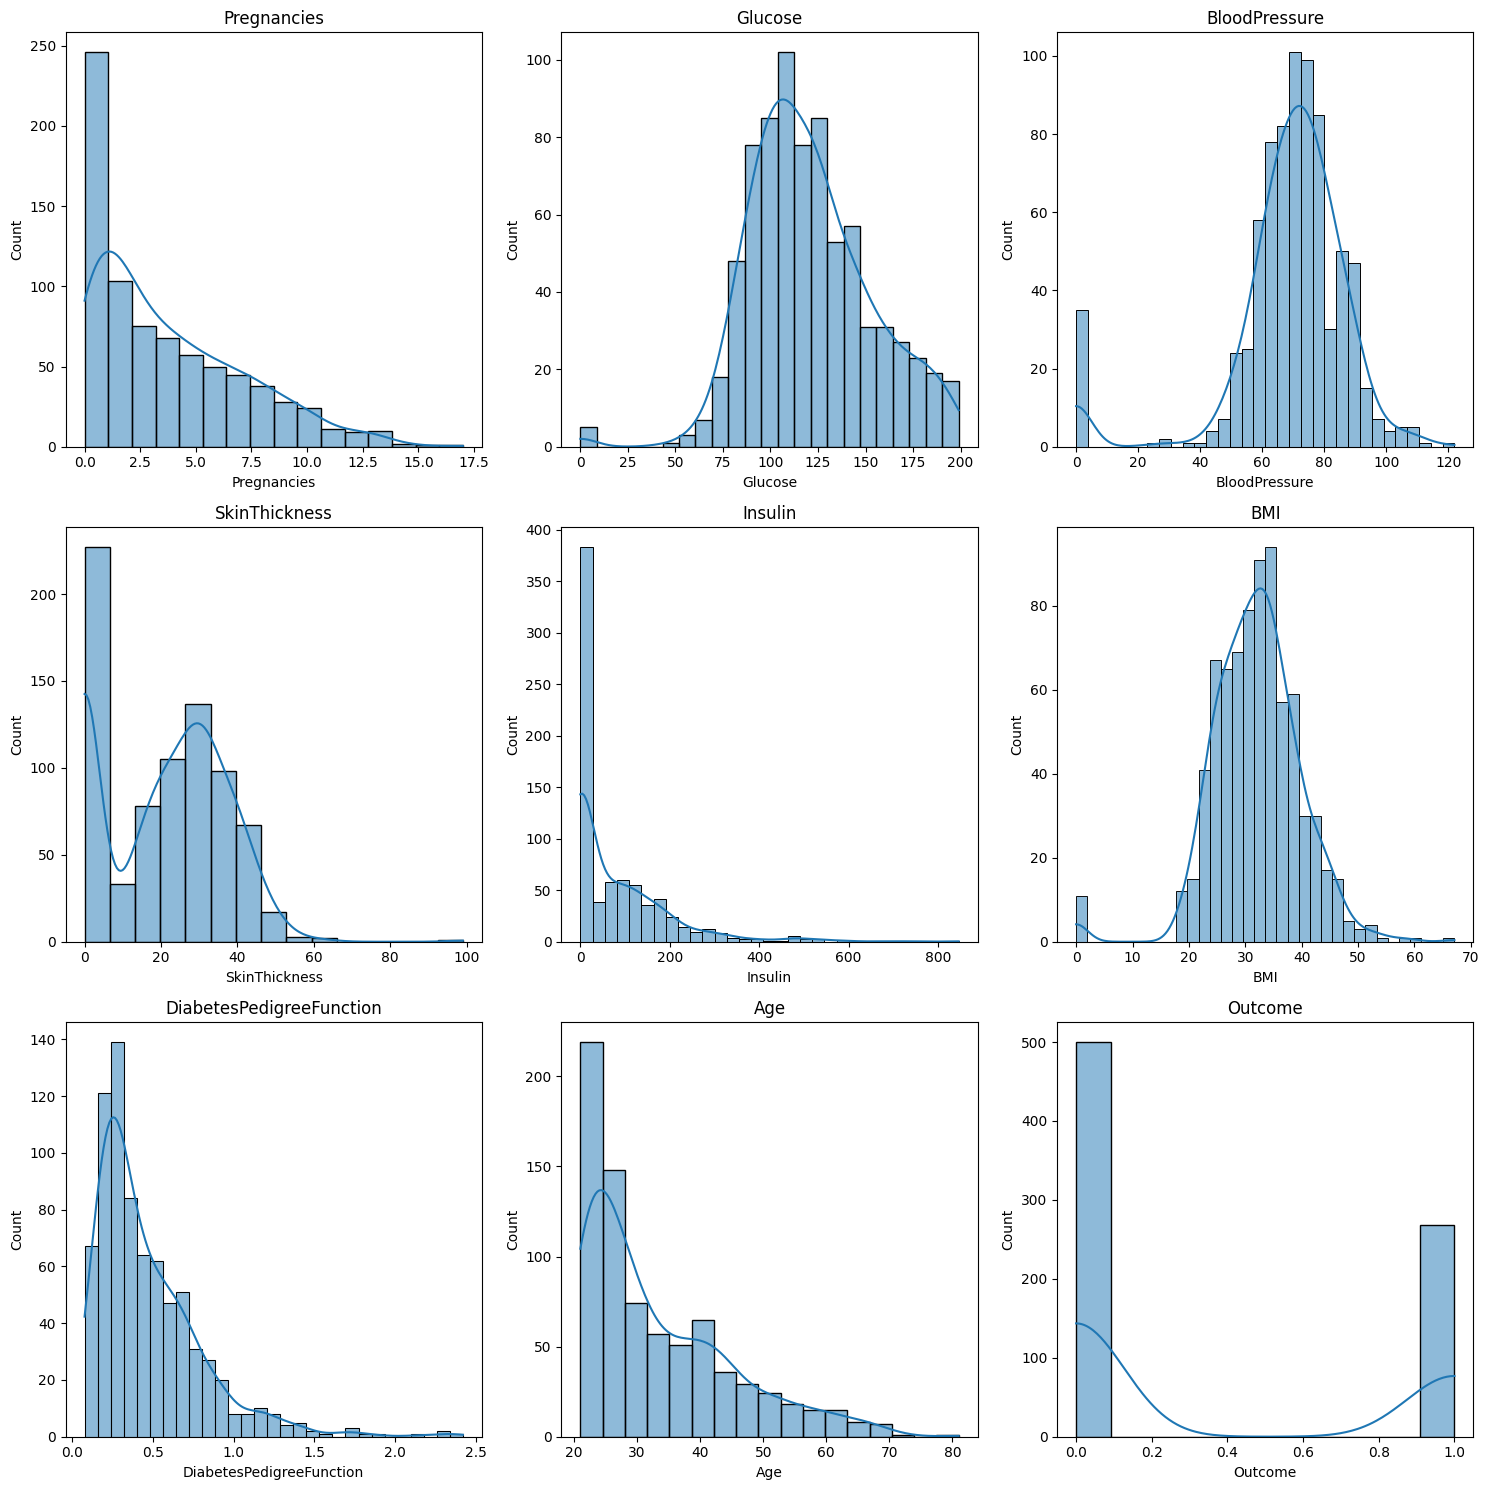

In [195]:
cols = df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show();

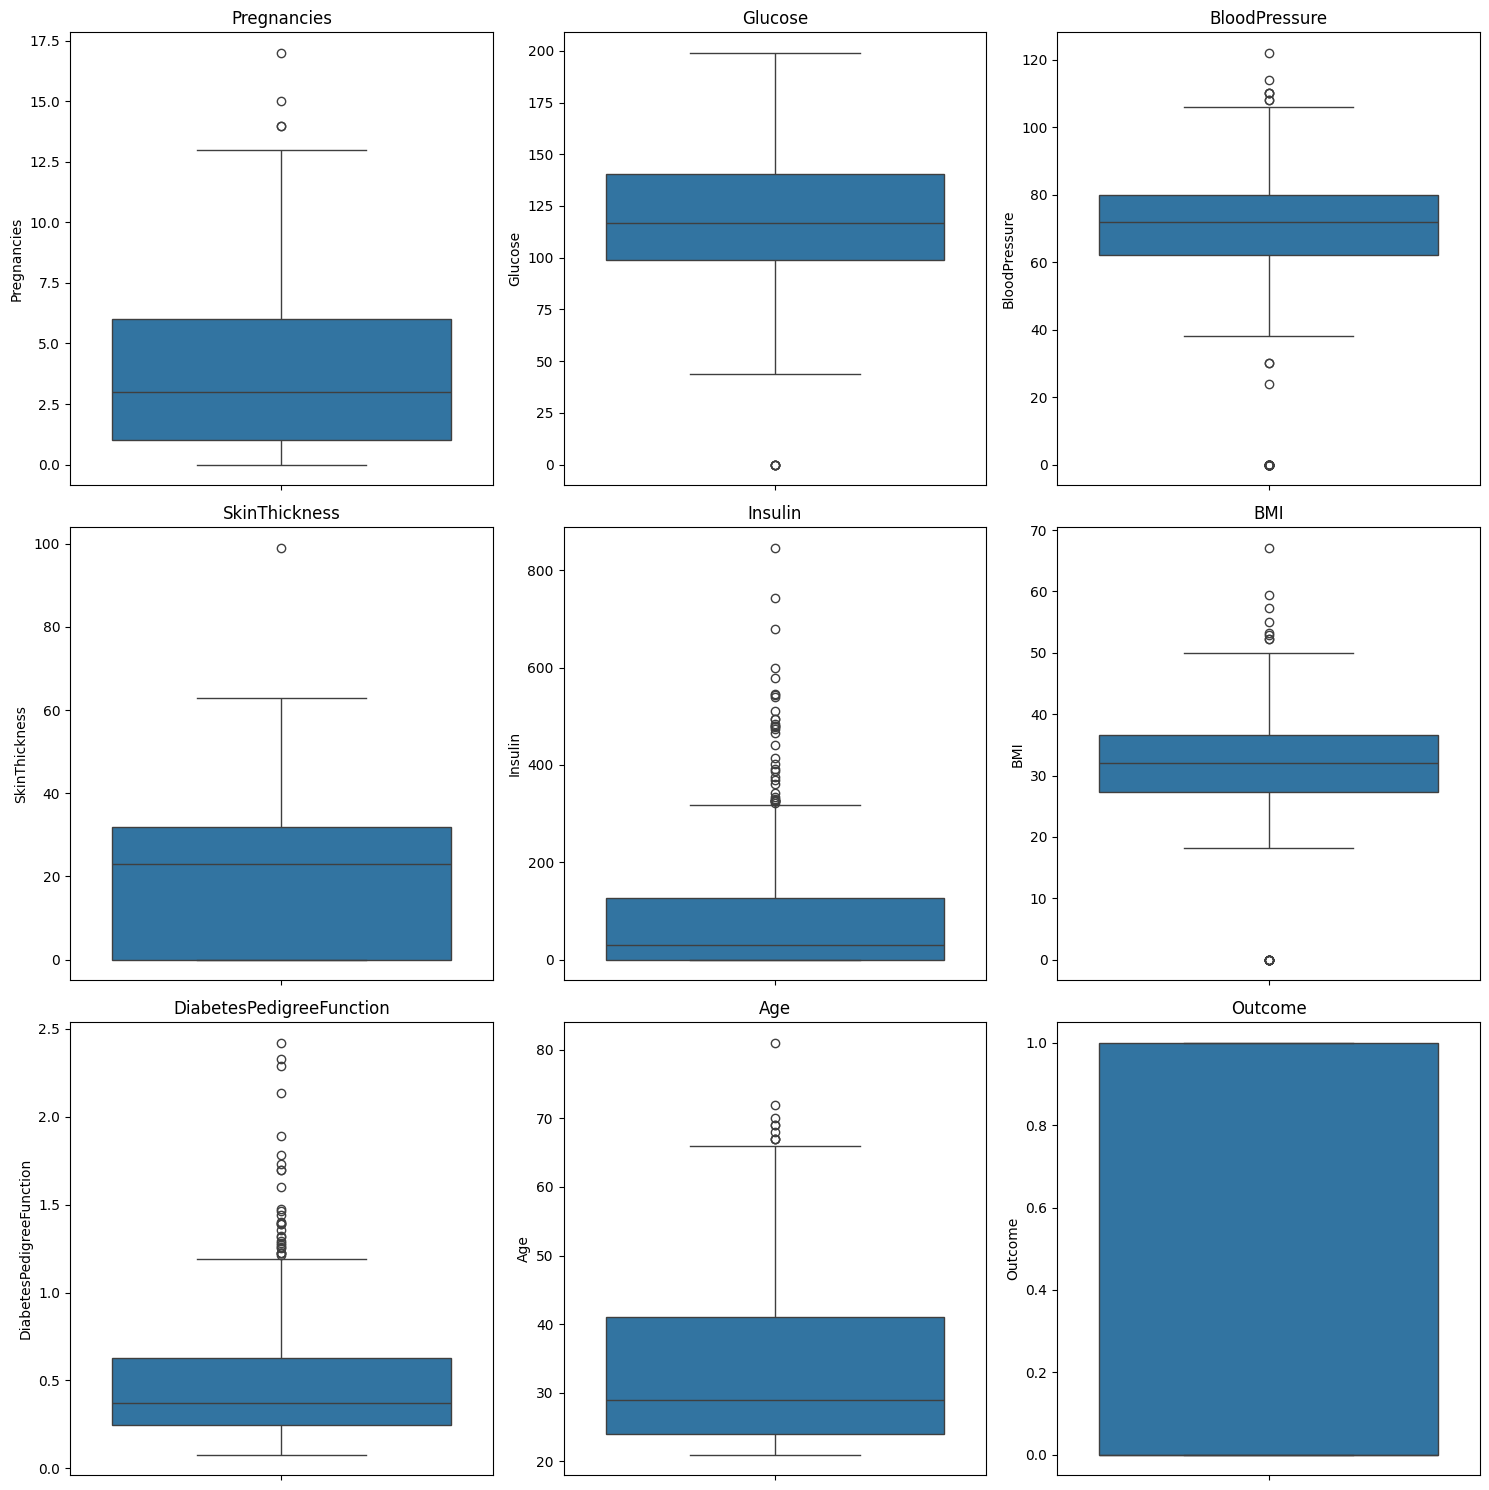

In [196]:
cols = df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show();

<Axes: xlabel='Outcome', ylabel='count'>

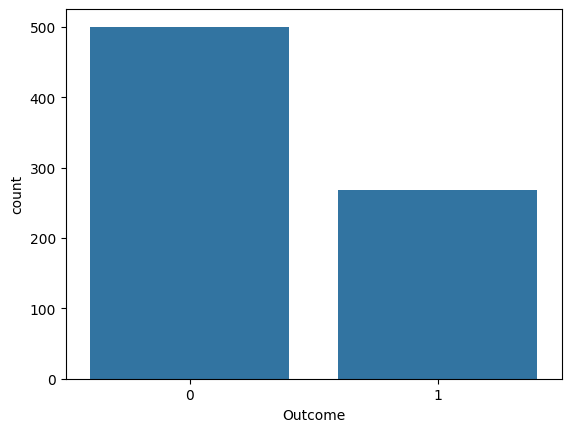

In [197]:
sns.countplot(x=df["Outcome"])

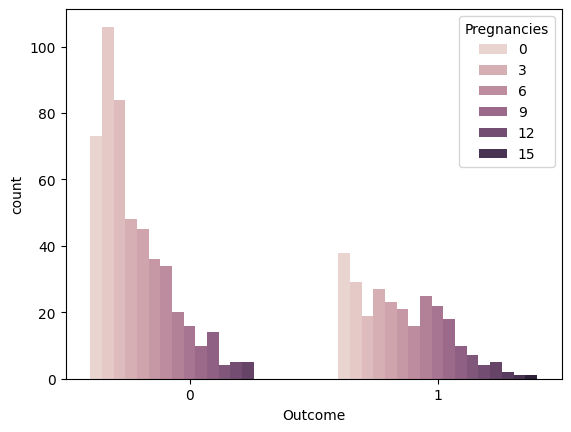

In [198]:
sns.countplot(x=df["Outcome"],hue=df["Pregnancies"]);

# ***Data Preprocessing***

In [199]:
for col in df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


In [200]:
X = df.drop("Outcome",axis=1)
y = df["Outcome"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [202]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [209]:
models = {
    "KNN": (
        KNeighborsClassifier(),
        {
            'n_neighbors': [3,5,7,9],
            'weights': ['uniform','distance']
        }
    ),

    "LogisticRegression": (
        LogisticRegression(max_iter=1000,class_weight='balanced'),
        {
            'C': [0.01,0.1,1,10]
        }
    ),

    "DecisionTree": (
        DecisionTreeClassifier(class_weight='balanced'),
        {
            'max_depth': [None,5,10,20],
            'min_samples_split': [2,5,10]
        }
    ),

    "RandomForest": (
        RandomForestClassifier(class_weight='balanced'),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5]
        }
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "AdaBoost": (
        AdaBoostClassifier(),
        {
            'n_estimators': [50,100],
            'learning_rate': [0.01,0.1,1]
        }
    ),

    "ExtraTrees": (
        ExtraTreesClassifier(),
        {
            'n_estimators': [200, 300],
            'max_depth': [6, 8, 10],
            'min_samples_leaf': [5, 10],
            'bootstrap': [True]
        }
    ),

    "XGBoost": (
        XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1],
            'max_depth': [3,6]
        }
    ),

    "SVC": (
        SVC(probability=True),
        {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    ),

    "LightGBM": (
        LGBMClassifier(verbose=-1),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "CatBoost": (
        CatBoostClassifier(silent=True),
        {
            'iterations': [100,200],
            'learning_rate': [0.01,0.1],
            'depth': [4,6]
        }
    )
}

In [210]:
results = []

for name, (model, param_grid) in models.items():

    print(f"Training {name}...")

    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    if hasattr(best_model, "predict_proba"):
        roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
    else:
        roc_auc = np.nan

    results.append({
        "Model": name,
        "Best Params": best_params,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
    })

Training KNN...


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='roc_auc')

Training LogisticRegression...


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 10]},
             scoring='roc_auc')

Training DecisionTree...


...

GridSearchCV(cv=5, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='roc_auc')

Training LightGBM...


GridSearchCV(cv=5, estimator=LGBMClassifier(verbose=-1), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

Training CatBoost...


GridSearchCV(cv=5, estimator=CatBoostClassifier(silent=True), n_jobs=-1,
             param_grid={'depth': [4, 6], 'iterations': [100, 200],
                         'learning_rate': [0.01, 0.1]},
             scoring='roc_auc')

In [212]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)
results_df

,Model,Best Params,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,"{'n_neighbors': 9, 'weights': 'distance'}",1.00000,0.790,0.739837,0.900990,0.812500,0.872187
1,CatBoost,"{'depth': 6, 'iterations': 200, 'learning_rate...",1.00000,0.805,0.762712,0.891089,0.821918,0.863386
2,RandomForest,"{'max_depth': 7, 'min_samples_split': 5, 'n_es...",0.91375,0.800,0.756303,0.891089,0.818182,0.862586
3,LightGBM,"{'learning_rate': 0.1, 'n_estimators': 100}",1.00000,0.805,0.767241,0.881188,0.820276,0.865587
4,ExtraTrees,"{'bootstrap': True, 'max_depth': 10, 'min_samp...",0.84125,0.800,0.760684,0.881188,0.816514,0.859386
5,DecisionTree,"{'max_depth': 5, 'min_samples_split': 2}",0.84125,0.790,0.752137,0.871287,0.807339,0.822782
6,XGBoost,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.99750,0.795,0.763158,0.861386,0.809302,0.866587
7,GradientBoosting,"{'learning_rate': 0.1, 'n_estimators': 100}",0.91500,0.800,0.769912,0.861386,0.813084,0.861686
8,SVC,"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",0.85375,0.780,0.747826,0.851485,0.796296,0.832883
9,AdaBoost,"{'learning_rate': 1, 'n_estimators': 100}",0.83875,0.780,0.756757,0.831683,0.792453,0.809181


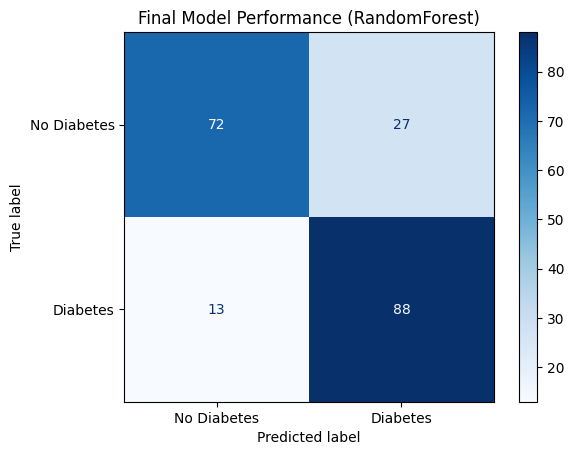

In [214]:
final_model = RandomForestClassifier(n_estimators=50,max_depth=7,min_samples_split=5)
final_model.fit(X_train,y_train)

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Final Model Performance (RandomForest)')
plt.show();

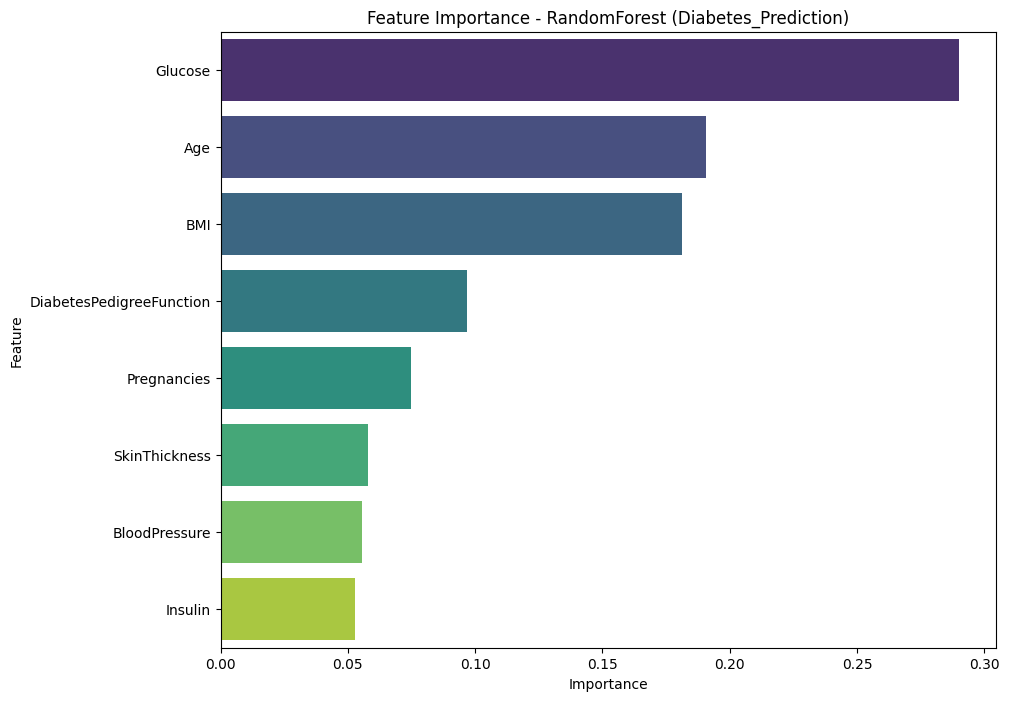

In [216]:
importances = final_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance - RandomForest (Diabetes_Prediction)')
plt.show();

In [217]:
feature_importance_df

,Feature,Importance
1,Glucose,0.289896
7,Age,0.190684
5,BMI,0.181371
6,DiabetesPedigreeFunction,0.096686
0,Pregnancies,0.074957
3,SkinThickness,0.057938
2,BloodPressure,0.055727
4,Insulin,0.052741


In [218]:
import joblib
joblib.dump(final_model, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')



['random_forest_model.pkl']

['scaler.pkl']